### KLDサンプリング
+ パーティクルフィルタのパーティクル個数を各ステップで可変にする仕組み
+ 空間 $χ$ をM個に分割した各ビン $s_j$ に存在するパーティクルの個数から各 $s_j$ にロボットの状態空間値 $\boldsymbol{x}$ が存在する確率を求める

In [1]:
from robot import *
from scipy.stats import norm, chi2 # ガウス分布, χ二乗分布

In [ ]:
def num(epsilon, delta, binnum): # 必要なパーティクル数
    # chi2.ppf(χ二乗分布の累積関数)が指定した確率、自由度に対して分位数を求める関数
    return math.ceil(chi2.ppf(1.0-delta, binnum-1)/(2*epsilon)) # 端数切り上げ

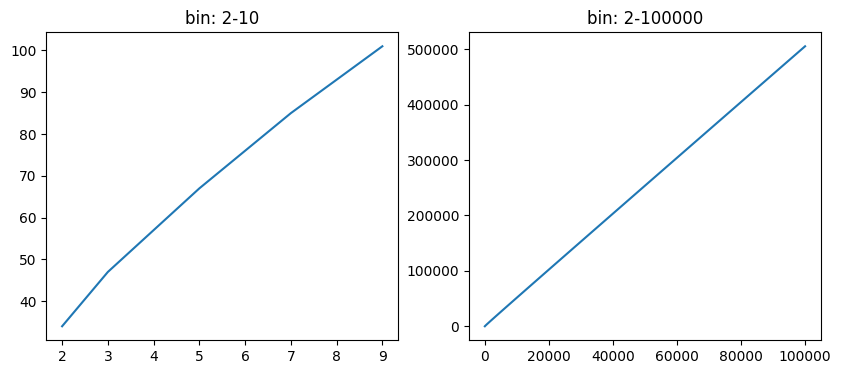

In [3]:
fig, (axl, axr) = plt.subplots(ncols=2, figsize=(10,4)) # 二つ横並びで図を出力する準備

bs = np.arange(2, 10)
n = [num(epsilon=0.1, delta=0.01, binnum=b) for b in bs] # ビン数: 2-10までのパーティクル数
axl.set_title("bin: 2-10")
axl.plot(bs, n)

bs = np.arange(2, 100000)
n = [num(0.1, 0.01, b) for b in bs] #ビンの数が2から100000までのパーティクルの数
axr.set_title("bin: 2-100000")
axr.plot(bs, n)

plt.show()

+ Python言語以外では、χ二乗分布の分位数を決める方法がない場合がある
+ この場合、ウィルソンーフィルファーティ(Wilson-Hilferty)変換という方法を使う方法がある

In [6]:
"""
ウィルソン - フィルファーティ変換
y = (k-1){1-2/9*(k-1)+sqrt(2/9*(k-1))*z_{1-δ}}^3

z_{1-δ} = N(0,1)を-∞から1-δまで積分した際の分位数
"""
def num_wh(epsilon, delta, binnum):
    dof = binnum-1 # (k-1)
    z = norm.ppf(1.0-delta) # 分位数
    return math.ceil(dof/(2*epsilon)*(1.0 - 2.0/(9*dof) + math.sqrt(2.0/(9*dof))*z)**3)


In [8]:
for binnum in 2, 4, 8, 1000, 10000, 100000: # 様々なビンの数で比較
    print("ビン：", binnum, "ε=0.1, δ=0.01", "\t", num(0.1, 0.01, binnum), "\t", num_wh(0.1, 0.01, binnum))
    print("ビン：", binnum, "ε=0.5, δ=0.01", "\t", num(0.5, 0.01, binnum), "\t", num_wh(0.5, 0.01, binnum))
    print("ビン：", binnum, "ε=0.5, δ=0.05", "\t", num(0.5, 0.05, binnum), "\t", num_wh(0.5, 0.05, binnum))

ビン： 2 ε=0.1, δ=0.01 	 34 	 33
ビン： 2 ε=0.5, δ=0.01 	 7 	 7
ビン： 2 ε=0.5, δ=0.05 	 4 	 4
ビン： 4 ε=0.1, δ=0.01 	 57 	 57
ビン： 4 ε=0.5, δ=0.01 	 12 	 12
ビン： 4 ε=0.5, δ=0.05 	 8 	 8
ビン： 8 ε=0.1, δ=0.01 	 93 	 93
ビン： 8 ε=0.5, δ=0.01 	 19 	 19
ビン： 8 ε=0.5, δ=0.05 	 15 	 15
ビン： 1000 ε=0.1, δ=0.01 	 5530 	 5530
ビン： 1000 ε=0.5, δ=0.01 	 1106 	 1106
ビン： 1000 ε=0.5, δ=0.05 	 1074 	 1074
ビン： 10000 ε=0.1, δ=0.01 	 51655 	 51655
ビン： 10000 ε=0.5, δ=0.01 	 10331 	 10331
ビン： 10000 ε=0.5, δ=0.05 	 10233 	 10233
ビン： 100000 ε=0.1, δ=0.01 	 505212 	 505212
ビン： 100000 ε=0.5, δ=0.01 	 101043 	 101043
ビン： 100000 ε=0.5, δ=0.05 	 100736 	 100736
